In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales: {collection.count_documents({}):,}")

total sales: 5,000


# Q10: Which products generated the highest total sales revenue across all sales transactions?

In [4]:
#code for Query 10
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "total_sales_revenue": {
                "$sum": {
                    "$multiply": [{"$toDouble":"$items.price"}, "$items.quantity"]
                }
            }
        }
    },
    {
        "$sort": {
            "total_sales_revenue": -1
        }
    }
]

revenue = list(collection.aggregate(pipeline))
pprint(revenue)

revenue_df = pd.DataFrame(revenue)
revenue_df.rename(columns={"_id": "Product Name", "total_sales_revenue": "Total Sales Revenue"}, inplace=True)

revenue_df

[{'_id': 'laptop', 'total_sales_revenue': 6775977.07},
 {'_id': 'backpack', 'total_sales_revenue': 817374.1},
 {'_id': 'pens', 'total_sales_revenue': 581843.27},
 {'_id': 'binder', 'total_sales_revenue': 511644.57},
 {'_id': 'notepad', 'total_sales_revenue': 463615.48},
 {'_id': 'envelopes', 'total_sales_revenue': 376658.49},
 {'_id': 'printer paper', 'total_sales_revenue': 367459.29}]


,Product Name,Total Sales Revenue
0,laptop,6775977.07
1,backpack,817374.10
2,pens,581843.27
3,binder,511644.57
4,notepad,463615.48
5,envelopes,376658.49
6,printer paper,367459.29


In [12]:
data = revenue_df["Product Name"].tolist()

print(f"The Highest Total Sales Revenue is generated by the product:  **{data[0]}** with a total sales revenue of **${revenue_df['Total Sales Revenue'][0]:,.2f}**")

The Highest Total Sales Revenue is generated by the product:  **laptop** with a total sales revenue of **$6,775,977.07**


## Code for Visualization

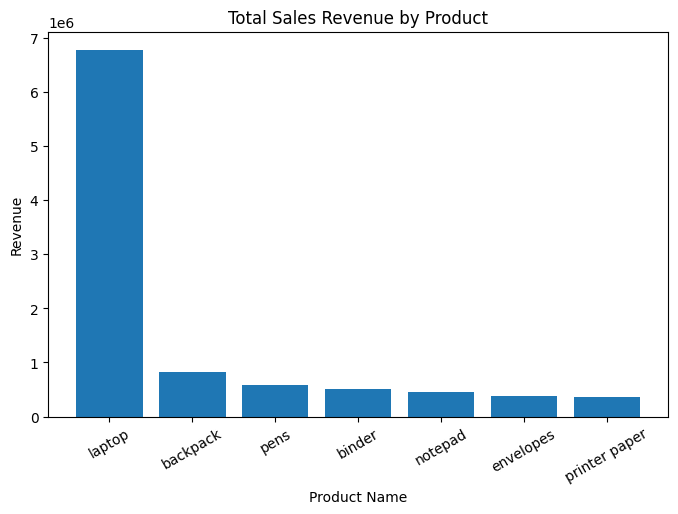

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    revenue_df["Product Name"],
    revenue_df["Total Sales Revenue"]
)

plt.title("Total Sales Revenue by Product")
plt.xlabel("Product Name")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.show()